In [1]:
import pandas as pd
import numpy as np
import math
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from datetime import datetime
from scipy import stats
import warnings
import os
import pickle
from dateutil.relativedelta import relativedelta
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')
import matplotlib as mpl
warnings.filterwarnings("ignore")
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['font.size'] = 12

In [2]:
# 0 -- 6 month
# 1 -- 2 year
# 2 -- 5 year
# 3 -- 10 year

rate_reg = 3
window_size = 373

In [3]:
load_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Data\Database_Regression.xlsx'
mergedData = pd.read_excel(load_path,index_col=[0],parse_dates=[0])
mergedData = mergedData.loc[datetime(2000,1,1):datetime(2025,1,1),[
    'SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd',
    'SwapESTR6Mm','SwapESTR2Ym','SwapESTR5Ym','SwapESTR10Ym',
    'OASd','EASurprise','USSurprise'
]]
mergedData.dropna(inplace=True)
    
diff_rates_clean = mergedData.loc[:,['SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']]

z = np.abs(stats.zscore(diff_rates_clean))
threshold = 10

outliers = pd.concat([diff_rates_clean[z.SwapESTR6Md>threshold],diff_rates_clean[z.SwapESTR2Yd>threshold],
                     diff_rates_clean[z.SwapESTR5Yd>threshold],diff_rates_clean[z.SwapESTR10Yd>threshold],
                     diff_rates_clean.loc[datetime(2023,3,13):datetime(2023,3,15)]],axis=0)

outliers.reset_index(inplace=True,drop=False)
outliers.drop_duplicates(subset='Date',inplace=True)
outliers.sort_values(by='Date',inplace=True,ignore_index=True)
outliers.set_index('Date',inplace=True,drop=True)

diff_rates_clean.drop(outliers.index,inplace=True,axis=0)

idx = diff_rates_clean.index

mergedData = mergedData.loc[idx]

In [4]:
ratevol_estr = mergedData.loc[:,['SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']].fillna(method='ffill').rolling(window=5,closed='left').std()
ratevol_estr = (ratevol_estr - ratevol_estr.mean())/ratevol_estr.std()
for j in ratevol_estr.columns:
    ratevol_estr.rename(columns={j: j.replace('Yd','Yv')},inplace=True)
    ratevol_estr.rename(columns={j: j.replace('Md','Mv')},inplace=True)

diff_rates_estr = mergedData.loc[:,['SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']]

df_momentum_estr = mergedData.loc[:,['SwapESTR6Mm','SwapESTR2Ym','SwapESTR5Ym','SwapESTR10Ym']]
df_momentum_estr.fillna(method='ffill',inplace=True)
df_momentum_estr = (df_momentum_estr - df_momentum_estr.mean())/df_momentum_estr.std()

diff_oas = mergedData.loc[:,['OASd']]
diff_oas = (diff_oas - diff_oas.mean())/diff_oas.std()

df_surprise_ea = mergedData.loc[:,['EASurprise']]
df_surprise_ea = (df_surprise_ea - df_surprise_ea.mean())/df_surprise_ea.std()

df_surprise_us = mergedData.loc[:,['USSurprise']]
df_surprise_us = (df_surprise_us - df_surprise_us.mean())/df_surprise_us.std()

In [5]:
df_reg = pd.concat([diff_rates_estr.iloc[:,rate_reg],
                    df_surprise_ea,df_surprise_us,
                    df_momentum_estr.iloc[:,rate_reg],ratevol_estr.iloc[:,rate_reg],diff_oas],axis=1)
    
Y = df_reg.iloc[:,[0]]
X = df_reg.iloc[:,1:]
X = sm.add_constant(X)

reg_range = range(0,(len(Y)-window_size)-1,1)
constant = list()
constant_ub = list()
constant_lb = list()
surprise_ea = list()
surprise_ea_ub = list()
surprise_ea_lb = list()
surprise_us = list()
surprise_us_ub = list()
surprise_us_lb = list()
momentum = list()
momentum_ub = list()
momentum_lb = list()
vol = list()
vol_ub = list()
vol_lb = list()
oas = list()
oas_ub = list()
oas_lb = list()
rsquared = list()
reg_date = list()
df_anova = pd.DataFrame()

for i in reg_range:
    y = Y.iloc[i:(window_size+i)].astype(float)
    x = X.iloc[i:(window_size+i)].astype(float)
    model = sm.OLS(y, x, missing='drop').fit(cov_type='HAC',cov_kwds={'maxlags':math.ceil(0.75*len(y)**(1/3))})
    conf_int = model.conf_int(alpha=0.10)
    
    constant.append(model.params[0])
    constant_lb.append(conf_int.iloc[0,0])
    constant_ub.append(conf_int.iloc[0,1])
    
    surprise_ea.append(model.params[1])
    surprise_ea_lb.append(conf_int.iloc[1,0])
    surprise_ea_ub.append(conf_int.iloc[1,1])
    
    surprise_us.append(model.params[2])
    surprise_us_lb.append(conf_int.iloc[2,0])
    surprise_us_ub.append(conf_int.iloc[2,1])
    
    momentum.append(model.params[3])
    momentum_lb.append(conf_int.iloc[3,0])
    momentum_ub.append(conf_int.iloc[3,1])
    
    vol.append(model.params[4])
    vol_lb.append(conf_int.iloc[4,0])
    vol_ub.append(conf_int.iloc[4,1])
    
    oas.append(model.params[5])
    oas_lb.append(conf_int.iloc[5,0])
    oas_ub.append(conf_int.iloc[5,1])
    
    rsquared.append(model.rsquared)
    reg_date.append(Y.index[i+math.floor(window_size)])

    df = pd.concat([y,x],axis=1)
    df.drop('const',axis=1,inplace=True)
    df.columns = ['Y','EA','US','Momentum','Volatility','OAS']
    mod = smf.ols(formula='Y ~ EA + US + Momentum + Volatility + OAS', data=df).fit(cov_type='HAC',cov_kwds={'maxlags':math.ceil(0.75*len(y)**(1/3))})
    anova = sm.stats.anova_lm(mod)
    df_anova_new = pd.DataFrame(anova.sum_sq/sum(anova.sum_sq))
    df_anova_new = df_anova_new.transpose()
    df_anova_new['Date'] = reg_date[-1]
    df_anova = pd.concat([df_anova,df_anova_new],axis=0)
    
output_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output'
os.chdir(output_path)
dff = pd.DataFrame(data={'EA_lb':surprise_ea_lb,'EA':surprise_ea,'EA_ub':surprise_ea_ub,
                         'US_lb':surprise_us_lb,'US':surprise_us,'US_ub':surprise_us_ub},index=reg_date)
name = Y.columns[0][:-1] + '_rolling'
name = name.replace('Swap','')
dff.to_pickle(name)

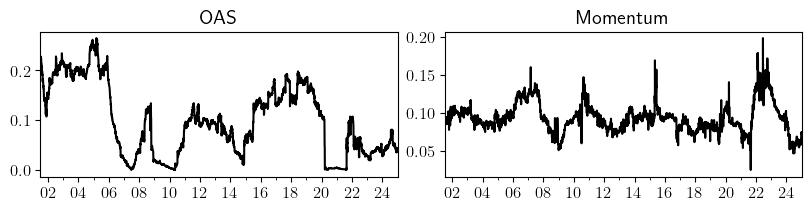

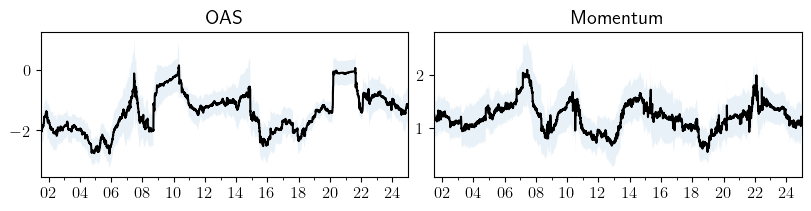

In [6]:
df_anova.set_index('Date',inplace=True,drop=True)

datemin = np.datetime64(reg_date[0])
datemax = np.datetime64(reg_date[-1])
fmt_major = mdates.YearLocator(2, month = 1, day = 1)
fmt_minor = mdates.YearLocator(1, month = 1, day = 1)
plt.rcParams['text.usetex'] = True

fig,ax = plt.subplots(1, 2,figsize=(8,2),constrained_layout=True)
ax[0].plot(df_anova.index,df_anova.OAS,color='k')
# ax2a.axhline(y = 0, color = 'k', linestyle = ':')
ax[0].set_xlim(datemin, datemax)
ax[0].set_title('OAS')
ax[0].xaxis.set_major_locator(fmt_major)
ax[0].xaxis.set_minor_locator(fmt_minor)
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax[1].plot(df_anova.index,df_anova.Momentum,color='k')
ax[1].set_xlim(datemin, datemax)
ax[1].set_title('Momentum')
ax[1].xaxis.set_major_locator(fmt_major)
ax[1].xaxis.set_minor_locator(fmt_minor)
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%y'))

fig,ax = plt.subplots(1, 2,figsize=(8,2),constrained_layout=True)
ax[0].plot(reg_date,oas,color='k')
ax[0].fill_between(reg_date,oas_lb,oas_ub,alpha=0.1)
ax[0].set_xlim(datemin, datemax)
ax[0].set_title('OAS')
ax[0].xaxis.set_major_locator(fmt_major)
ax[0].xaxis.set_minor_locator(fmt_minor)
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax[1].plot(reg_date,momentum,color='k')
ax[1].fill_between(reg_date,momentum_lb,momentum_ub,alpha=0.1)
ax[1].set_xlim(datemin, datemax)
ax[1].set_title('Momentum')
ax[1].xaxis.set_major_locator(fmt_major)
ax[1].xaxis.set_minor_locator(fmt_minor)
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%y'))

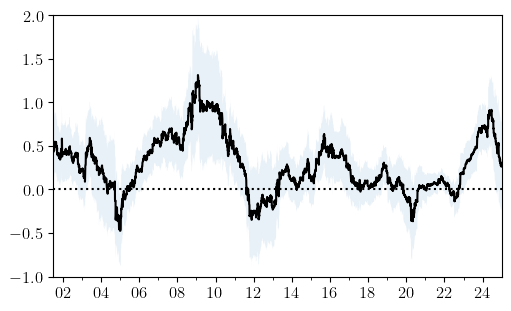

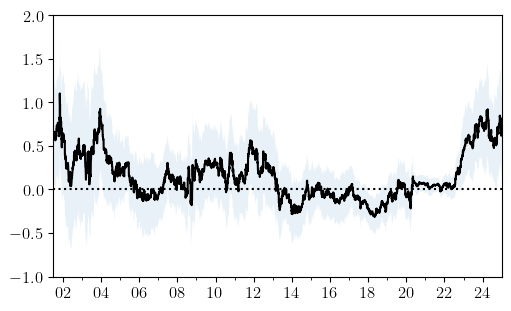

In [7]:
datemin = np.datetime64(reg_date[0])
datemax = np.datetime64(reg_date[-1])
fmt_major = mdates.YearLocator(2, month = 1, day = 1)
fmt_minor = mdates.YearLocator(1, month = 1, day = 1)
plt.rcParams['text.usetex'] = True

name_ea = name + '_ea'
fig,(ax2a) = plt.subplots(1, 1,figsize=(5,3),constrained_layout=True)
ax2a.plot(reg_date,surprise_ea,color='k')
ax2a.axhline(y = 0, color = 'k', linestyle = ':')
ax2a.fill_between(reg_date,surprise_ea_lb,surprise_ea_ub,alpha=0.1)
ax2a.set_xlim(datemin, datemax)
ax2a.set_ylim(-1, 2)
ax2a.xaxis.set_major_locator(fmt_major)
ax2a.xaxis.set_minor_locator(fmt_minor)
ax2a.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
plt.savefig(name_ea,bbox_inches="tight",dpi=200)

name_us = name + '_us'
fig,(ax2b) = plt.subplots(1, 1,figsize=(5,3),constrained_layout=True)
ax2b.plot(reg_date,surprise_us,color='k')
ax2b.axhline(y = 0, color = 'k', linestyle = ':')
ax2b.fill_between(reg_date,surprise_us_lb,surprise_us_ub,alpha=0.1)
ax2b.set_xlim(datemin, datemax)
ax2b.set_ylim(-1, 2)
ax2b.xaxis.set_major_locator(fmt_major)
ax2b.xaxis.set_minor_locator(fmt_minor)
ax2b.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
plt.savefig(name_us,bbox_inches="tight",dpi=200)